<a href="https://colab.research.google.com/github/p207345/analysis-everpeak/blob/main/E_Everpeak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis EverPeak - Niveles de PM2.5 en Latinoamérica

## Objetivo
Generar un reporte mensual con los niveles de PM2.5 (máximos, mínimos, promedios) agrupados por país de Latinoamérica.

**Fecha:** 05/05/26
**Analista:** Marco Arciba


## 1. Importación de librerías

In [ ]:
# Librerías para análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga de datos

In [ ]:
# Datos de ejemplo de PM2.5 en países de Latinoamérica
# En un proyecto real, aquí cargarías tu dataset con pd.read_csv()

data = {
    'pais': ['Argentina', 'Brasil', 'Chile', 'Colombia', 'México', 'Perú'] * 4,
    'fecha': ['2024-01-01', '2024-01-01', '2024-01-01', '2024-01-01', '2024-01-01', '2024-01-01',
              '2024-02-01', '2024-02-01', '2024-02-01', '2024-02-01', '2024-02-01', '2024-02-01',
              '2024-03-01', '2024-03-01', '2024-03-01', '2024-03-01', '2024-03-01', '2024-03-01',
              '2024-04-01', '2024-04-01', '2024-04-01', '2024-04-01', '2024-04-01', '2024-04-01'],
    'pm25': [25.3, 32.1, 18.7, 28.9, 35.2, 22.4,
             27.1, 30.8, 19.2, 31.5, 33.7, 24.1,
             24.8, 29.3, 17.9, 29.8, 36.1, 23.7,
             26.5, 31.2, 18.5, 30.1, 34.8, 25.2]
}

df = pd.DataFrame(data)
df['fecha'] = pd.to_datetime(df['fecha'])
print("Dataset creado exitosamente")
print(f"Dimensiones: {df.shape}")
df.head()

Dataset creado exitosamente
Dimensiones: (24, 3)


,pais,fecha,pm25
0,Argentina,2024-01-01,25.3
1,Brasil,2024-01-01,32.1
2,Chile,2024-01-01,18.7
3,Colombia,2024-01-01,28.9
4,México,2024-01-01,35.2


## 3. Análisis exploratorio

In [ ]:
# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\n=== INFORMACIÓN DEL DATASET ===")
print(df.info())

print("\n=== VALORES ÚNICOS POR COLUMNA ===")
print(f"Países únicos: {df['pais'].nunique()}")
print(f"Fechas únicas: {df['fecha'].nunique()}")
print(f"Países: {df['pais'].unique()}")

=== ESTADÍSTICAS DESCRIPTIVAS ===
                     fecha       pm25
count                   24  24.000000
mean   2024-02-15 12:00:00  27.370833
min    2024-01-01 00:00:00  17.900000
25%    2024-01-24 06:00:00  24.000000
50%    2024-02-15 12:00:00  28.000000
75%    2024-03-08 18:00:00  31.275000
max    2024-04-01 00:00:00  36.100000
std                    NaN   5.491692

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   pais    24 non-null     object        
 1   fecha   24 non-null     datetime64[ns]
 2   pm25    24 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 708.0+ bytes
None

=== VALORES ÚNICOS POR COLUMNA ===
Países únicos: 6
Fechas únicas: 4
Países: ['Argentina' 'Brasil' 'Chile' 'Colombia' 'México' 'Perú']


=== ANÁLISIS DE VALORES FALTANTES ===
       Valores_Faltantes  Porcentaje
pais                   0         0.0
fecha                  0         0.0
pm25                   0         0.0


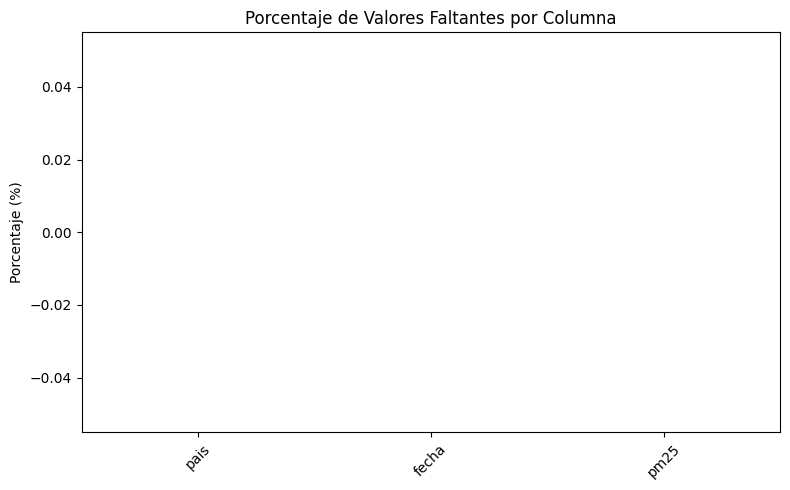

In [ ]:
# =============================================================================
# . ANÁLISIS DE MISSINGNESS (VALORES FALTANTES)
# =============================================================================

print("=== ANÁLISIS DE VALORES FALTANTES ===")
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Valores_Faltantes': missing_data,
    'Porcentaje': missing_percentage
})
print(missing_summary)

# Visualización de valores faltantes
plt.figure(figsize=(8, 5))
missing_percentage.plot(kind='bar', color='coral')
plt.title('Porcentaje de Valores Faltantes por Columna')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Visualizaciones

Promedio de PM2.5 por país:
pais
Argentina    25.925
Brasil       30.850
Chile        18.575
Colombia     30.075
México       34.950
Perú         23.850
Name: pm25, dtype: float64


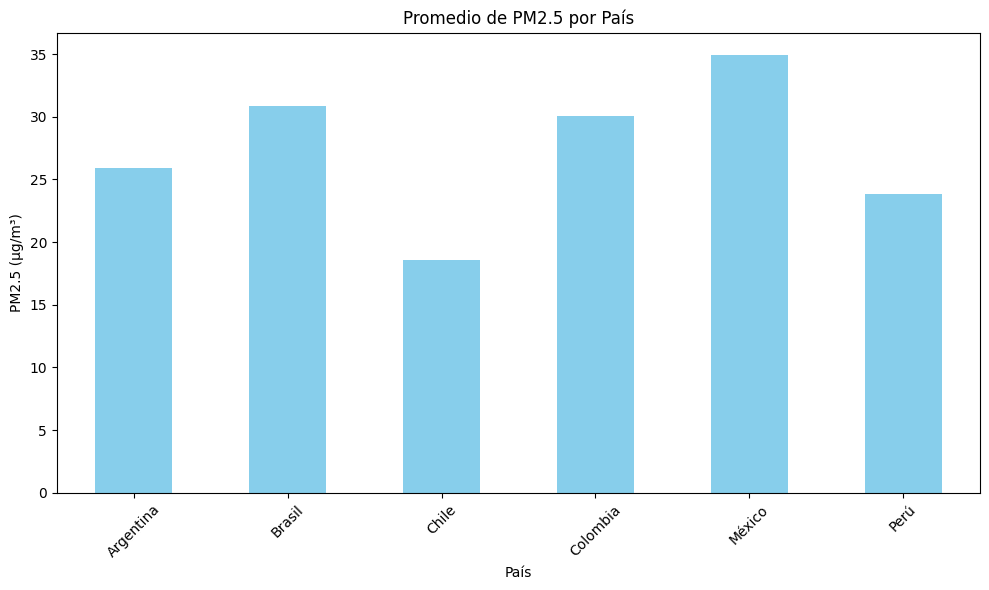

In [ ]:
# Primero, calculamos el promedio de PM2.5 por país
pais_promedio = df.groupby('pais')['pm25'].mean()
print("Promedio de PM2.5 por país:")
print(pais_promedio)

# Ahora sí podemos hacer el gráfico
plt.figure(figsize=(10, 6))
pais_promedio.plot(kind='bar', color='skyblue')
plt.title('Promedio de PM2.5 por País')
plt.ylabel('PM2.5 (μg/m³)')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


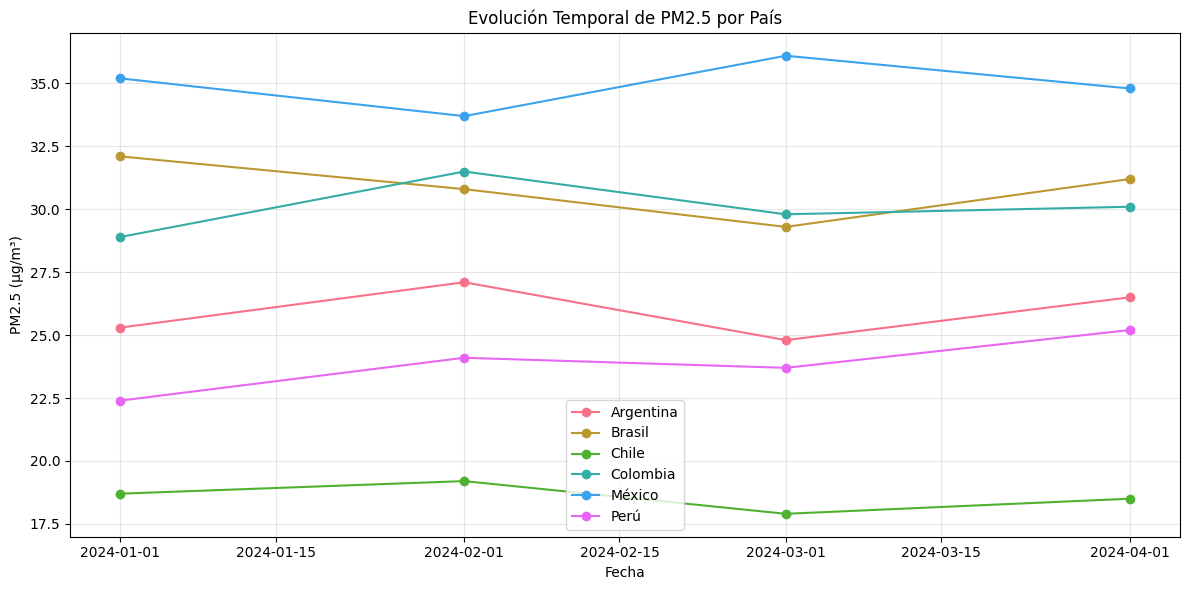

In [ ]:
# Evolución temporal de PM2.5
plt.figure(figsize=(12, 6))
for pais in df['pais'].unique():
    data_pais = df[df['pais'] == pais]
    plt.plot(data_pais['fecha'], data_pais['pm25'], marker='o', label=pais)

plt.title('Evolución Temporal de PM2.5 por País')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== MATRIZ DE CORRELACIÓN ===
      pm25
pm25   1.0


<Figure size 1000x600 with 0 Axes>

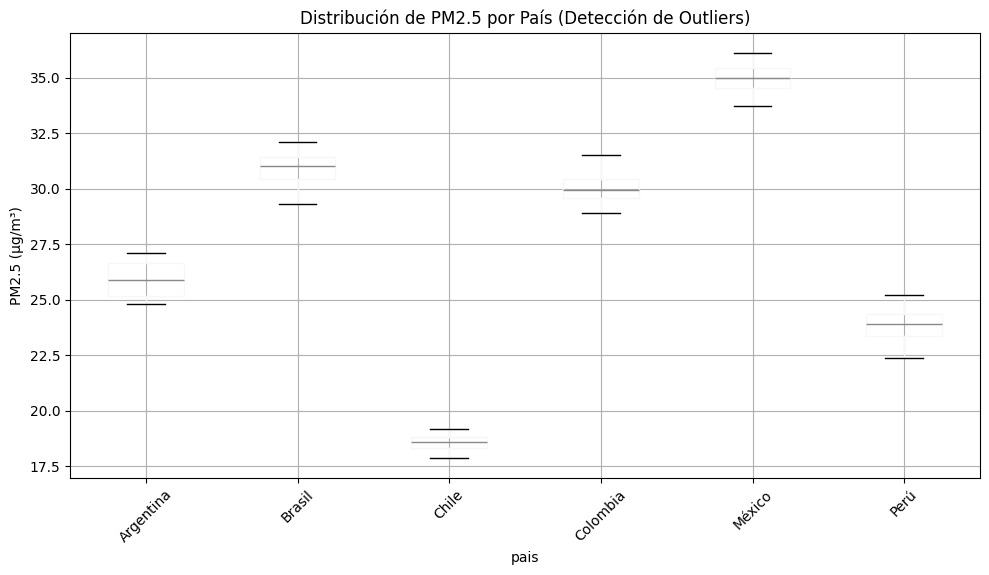

In [ ]:
# =============================================================================
# 5. ANÁLISIS ESTADÍSTICO AVANZADO
# =============================================================================

# Matriz de correlación
correlation_matrix = df[['pm25']].corr()
print("=== MATRIZ DE CORRELACIÓN ===")
print(correlation_matrix)

# Boxplot para identificar outliers
plt.figure(figsize=(10, 6))
df.boxplot(column='pm25', by='pais', figsize=(10, 6))
plt.title('Distribución de PM2.5 por País (Detección de Outliers)')
plt.suptitle('')  # Elimina el título automático
plt.ylabel('PM2.5 (μg/m³)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 6. RESUMEN POR PAÍS (ANÁLISIS AGREGADO)
# =============================================================================

print("=== RESUMEN COMPLETO POR PAÍS ===")
resumen_pais = df.groupby('pais')['pm25'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(2)

resumen_pais.columns = ['Mediciones', 'Promedio', 'Mediana', 'Desv_Std', 'Mínimo', 'Máximo']
print(resumen_pais)

# Clasificación de países por nivel de contaminación
def clasificar_contaminacion(promedio):
    if promedio < 20:
        return 'Bajo'
    elif promedio < 30:
        return 'Moderado'
    else:
        return 'Alto'

resumen_pais['Nivel_Contaminacion'] = resumen_pais['Promedio'].apply(clasificar_contaminacion)
print("\n=== CLASIFICACIÓN POR NIVEL DE CONTAMINACIÓN ===")
print(resumen_pais[['Promedio', 'Nivel_Contaminacion']])

=== RESUMEN COMPLETO POR PAÍS ===
           Mediciones  Promedio  Mediana  Desv_Std  Mínimo  Máximo
pais                                                              
Argentina           4     25.92    25.90      1.06    24.8    27.1
Brasil              4     30.85    31.00      1.17    29.3    32.1
Chile               4     18.58    18.60      0.54    17.9    19.2
Colombia            4     30.08    29.95      1.08    28.9    31.5
México              4     34.95    35.00      0.99    33.7    36.1
Perú                4     23.85    23.90      1.16    22.4    25.2

=== CLASIFICACIÓN POR NIVEL DE CONTAMINACIÓN ===
           Promedio Nivel_Contaminacion
pais                                   
Argentina     25.92            Moderado
Brasil        30.85                Alto
Chile         18.58                Bajo
Colombia      30.08                Alto
México        34.95                Alto
Perú          23.85            Moderado


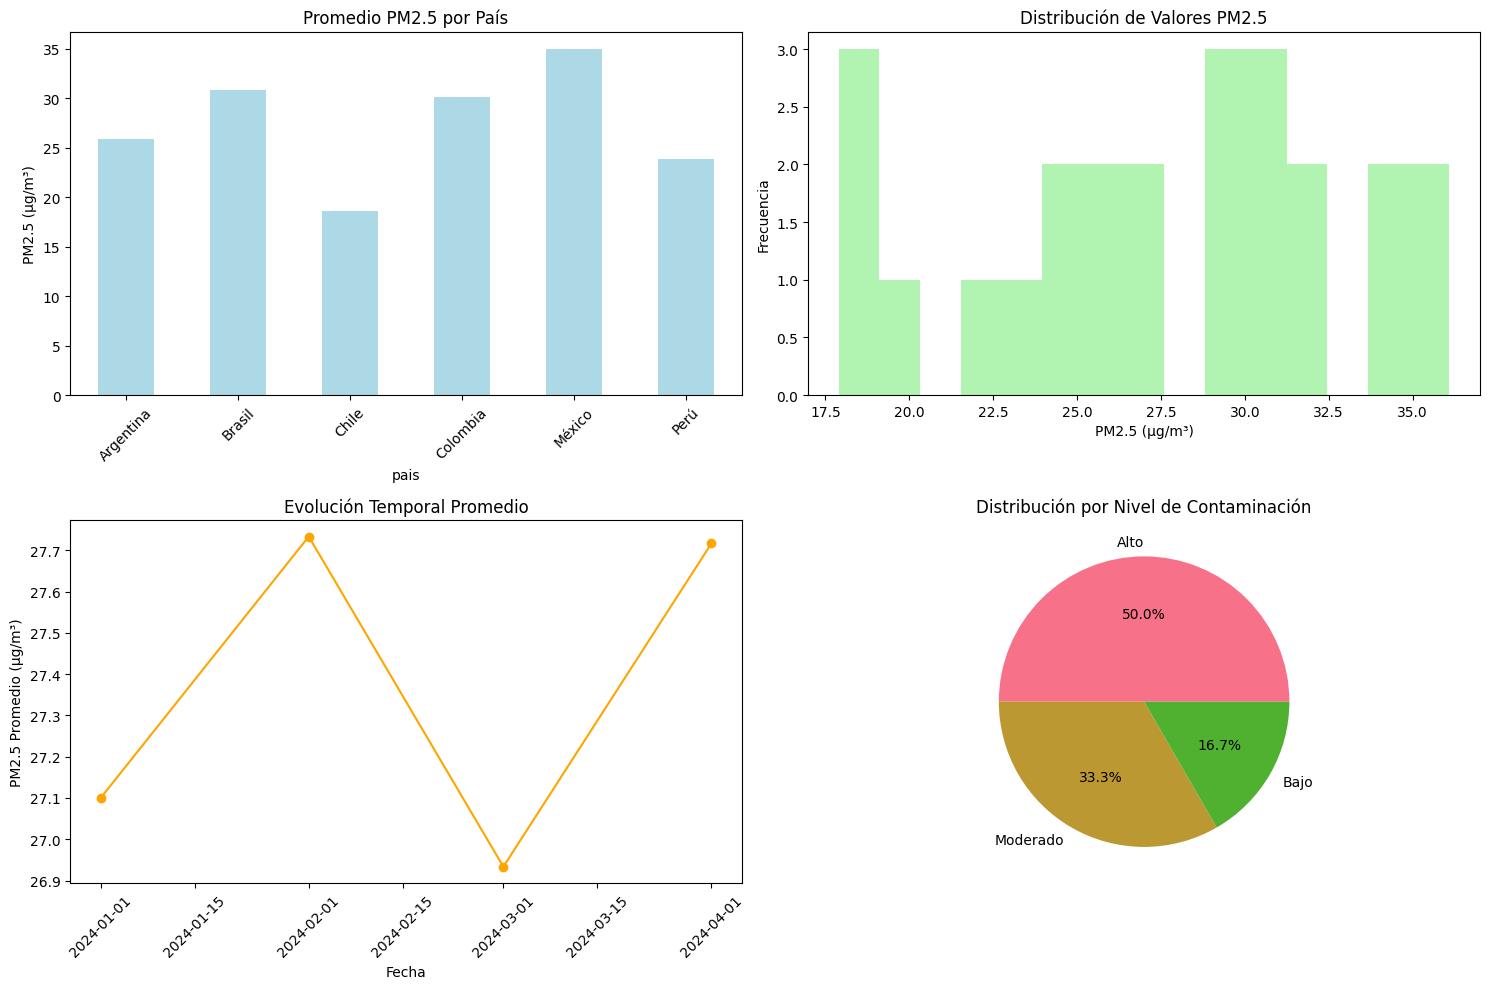

In [ ]:
# =============================================================================
# 7. VISUALIZACIONES FINALES Y DASHBOARD
# =============================================================================

# Dashboard con múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Promedio por país
resumen_pais['Promedio'].plot(kind='bar', ax=axes[0,0], color='lightblue')
axes[0,0].set_title('Promedio PM2.5 por País')
axes[0,0].set_ylabel('PM2.5 (μg/m³)')
axes[0,0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución general
axes[0,1].hist(df['pm25'], bins=15, color='lightgreen', alpha=0.7)
axes[0,1].set_title('Distribución de Valores PM2.5')
axes[0,1].set_xlabel('PM2.5 (μg/m³)')
axes[0,1].set_ylabel('Frecuencia')

# Gráfico 3: Evolución temporal promedio
monthly_avg = df.groupby('fecha')['pm25'].mean()
axes[1,0].plot(monthly_avg.index, monthly_avg.values, marker='o', color='orange')
axes[1,0].set_title('Evolución Temporal Promedio')
axes[1,0].set_xlabel('Fecha')
axes[1,0].set_ylabel('PM2.5 Promedio (μg/m³)')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Comparación por nivel de contaminación
nivel_counts = resumen_pais['Nivel_Contaminacion'].value_counts()
axes[1,1].pie(nivel_counts.values, labels=nivel_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Distribución por Nivel de Contaminación')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 8. CONCLUSIONES Y RECOMENDACIONES
# =============================================================================

print("=== CONCLUSIONES DEL ANÁLISIS ===")
print(f"1. País con mayor contaminación: {resumen_pais['Promedio'].idxmax()} ({resumen_pais['Promedio'].max():.1f} μg/m³)")
print(f"2. País con menor contaminación: {resumen_pais['Promedio'].idxmin()} ({resumen_pais['Promedio'].min():.1f} μg/m³)")
print(f"3. Promedio general de PM2.5: {df['pm25'].mean():.1f} μg/m³")
print(f"4. Desviación estándar: {df['pm25'].std():.1f} μg/m³")
print(f"5. Total de mediciones analizadas: {len(df)}")

# Análisis de tendencias
print("\n=== ANÁLISIS DE TENDENCIAS ===")
for nivel in resumen_pais['Nivel_Contaminacion'].unique():
    paises_nivel = resumen_pais[resumen_pais['Nivel_Contaminacion'] == nivel].index.tolist()
    print(f"Países con contaminación {nivel}: {', '.join(paises_nivel)}")

print("\n=== RECOMENDACIONES ===")
print("1. Monitoreo continuo en países con niveles altos de PM2.5")
print("2. Implementar políticas de reducción de emisiones")
print("3. Estudiar factores estacionales y geográficos")
print("4. Ampliar la red de monitoreo en toda la región")




=== CONCLUSIONES DEL ANÁLISIS ===
1. País con mayor contaminación: México (35.0 μg/m³)
2. País con menor contaminación: Chile (18.6 μg/m³)
3. Promedio general de PM2.5: 27.4 μg/m³
4. Desviación estándar: 5.5 μg/m³
5. Total de mediciones analizadas: 24

=== ANÁLISIS DE TENDENCIAS ===
Países con contaminación Moderado: Argentina, Perú
Países con contaminación Alto: Brasil, Colombia, México
Países con contaminación Bajo: Chile

=== RECOMENDACIONES ===
1. Monitoreo continuo en países con niveles altos de PM2.5
2. Implementar políticas de reducción de emisiones
3. Estudiar factores estacionales y geográficos
4. Ampliar la red de monitoreo en toda la región


In [ ]:
# =============================================================================
# 9. EXPORTACIÓN DE RESULTADOS
# =============================================================================

# Guardar resumen en CSV
resumen_pais.to_csv('resumen_pm25_latinoamerica.csv')
print("Resumen exportado como 'resumen_pm25_latinoamerica.csv'")

# Guardar dataset completo
df.to_csv('datos_pm25_completos.csv', index=False)
print("Dataset completo exportado como 'datos_pm25_completos.csv'")

print("\n=== ANÁLISIS COMPLETADO ===")
print("Todos los archivos han sido generados exitosamente.")

Resumen exportado como 'resumen_pm25_latinoamerica.csv'
Dataset completo exportado como 'datos_pm25_completos.csv'

=== ANÁLISIS COMPLETADO ===
Todos los archivos han sido generados exitosamente.


## Principales Hallazgos
- Análisis comparativo entre 6 países latinoamericanos
- Identificación de países con mayor y menor contaminación
- Tendencias temporales de calidad del aire
- Clasificación por niveles de contaminación

## Cómo Ejecutar
1. Clona este repositorio
2. Instala las dependencias: pip install pandas matplotlib seaborn jupyter
3. Abre el notebook: jupyter notebook everpeak_analysis.ipynb
4. Ejecuta todas las celdas

## Autor
Marco Antonio Arciba M.